In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Download Apple stock data (last 5 years)
df = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

# Use only 'Close' price
df = df[['Close']]
df.head()


C:\Users\stita\AppData\Local\Temp\ipykernel_6712\1629702529.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2020-01-02,72.538536
2020-01-03,71.833290
2020-01-06,72.405663
2020-01-07,72.065155
2020-01-08,73.224403


In [22]:
df

Price,Close
Ticker,AAPL
Date,
2020-01-02,72.538536
2020-01-03,71.833290
2020-01-06,72.405663
2020-01-07,72.065155
2020-01-08,73.224403
...,...
2024-12-24,257.286652
2024-12-26,258.103729


In [2]:
!pip install yfinance

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334



  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     ------------------------------------- 949.2/949.2 kB 20.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 30.3 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15618 sha256=2efd7012034d9590be7219a3868bd8d876faa03454749e54e413fd678975dcaf
  Stored in directory: c:\users\stita\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab

In [4]:
import yfinance as yf

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Download Apple stock data (last 5 years)
df = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

# Use only 'Close' price
df = df[['Close']]
df.head()


C:\Users\stita\AppData\Local\Temp\ipykernel_6712\1629702529.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2020-01-02,72.538536
2020-01-03,71.833290
2020-01-06,72.405663
2020-01-07,72.065155
2020-01-08,73.224403


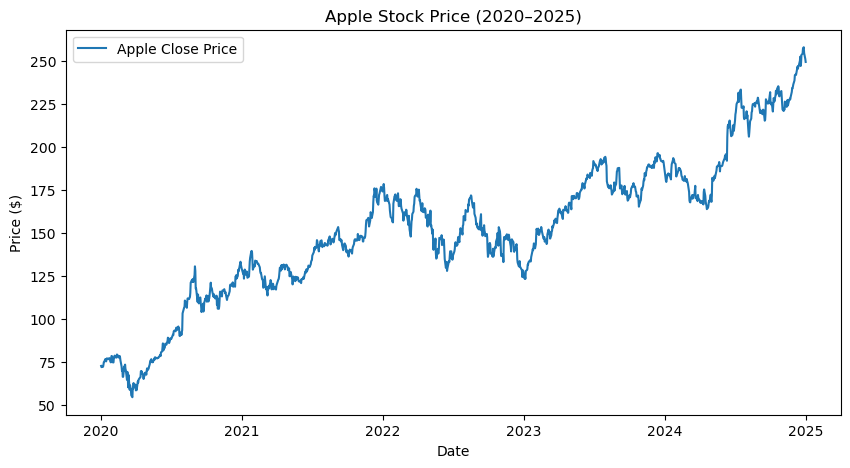

In [23]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Apple Close Price')
plt.title('Apple Stock Price (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()


In [8]:
result = adfuller(df['Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
# If p-value > 0.05, → data is non-stationary

# If p-value ≤ 0.05, → data is stationary

ADF Statistic: -0.7084047098558882
p-value: 0.8445605007361479


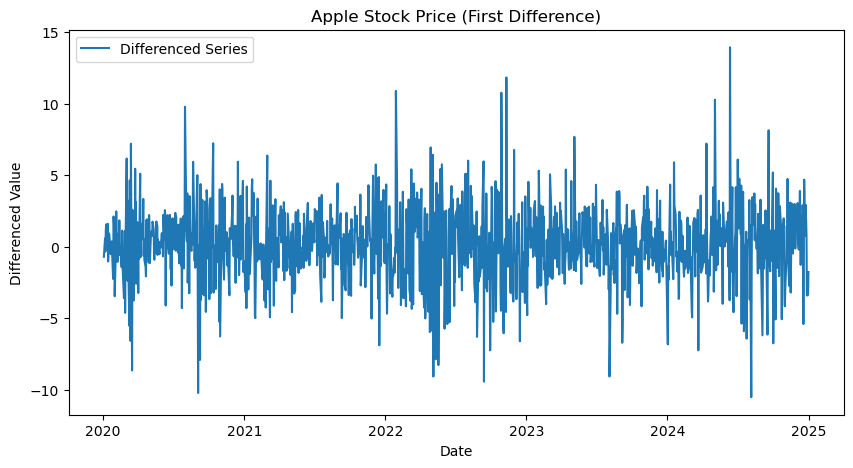

ADF Statistic: -35.93869013238687
p-value: 0.0


In [9]:
df['Close_diff'] = df['Close'].diff()

plt.figure(figsize=(10,5))
plt.plot(df['Close_diff'], label='Differenced Series')
plt.title('Apple Stock Price (First Difference)')
plt.xlabel('Date')
plt.ylabel('Differenced Value')
plt.legend()
plt.show()

# Test again
result = adfuller(df['Close_diff'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


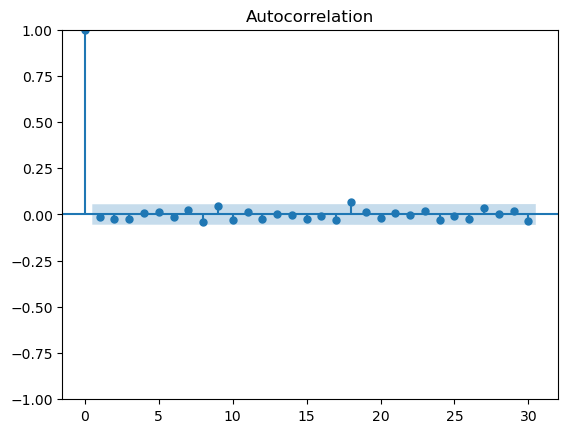

In [10]:
plot_acf(df['Close_diff'].dropna(), lags=30)
plt.show()


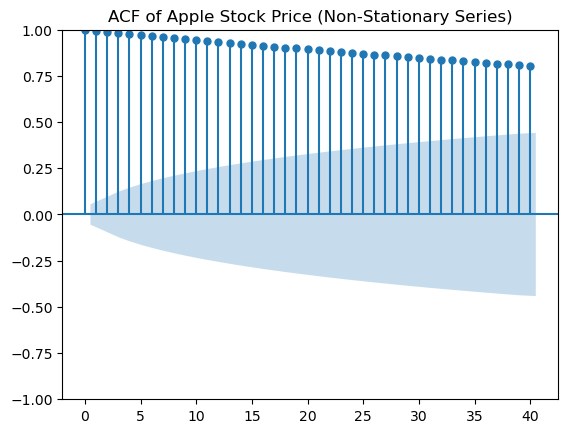

In [11]:
plot_acf(df['Close'], lags=40)
plt.title("ACF of Apple Stock Price (Non-Stationary Series)")
plt.show()


C:\Users\stita\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:472: RuntimeWarning: Mean of empty slice.
  xo = x - x.mean()
C:\Users\stita\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: negative dimensions are not allowed

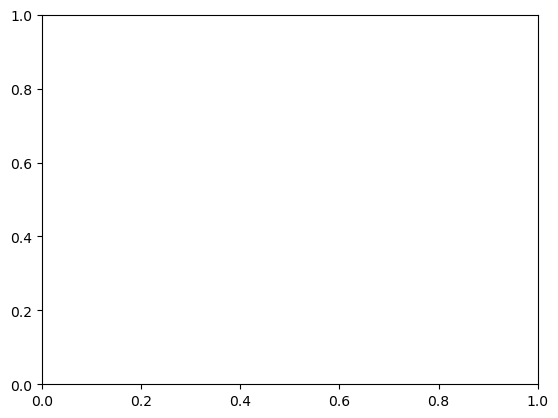

In [12]:
df['Close_diff'] = df['Close'].diff()
plot_acf(df['Close_diff'].dropna(), lags=40)
plt.title("ACF of Differenced Apple Stock (Stationary Series)")
plt.show()


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller


In [14]:
np.random.seed(42)
n = 200

# Generate two independent random walks
x = np.cumsum(np.random.normal(0, 1, n))   # X_t = X_{t-1} + noise
y = np.cumsum(np.random.normal(0, 1, n))   # Y_t = Y_{t-1} + noise

df = pd.DataFrame({'X': x, 'Y': y})
df.head()

,X,Y
0,0.496714,0.357787
1,0.358450,0.918572
2,1.006138,2.001623
3,2.529168,3.055425
4,2.295015,1.677756


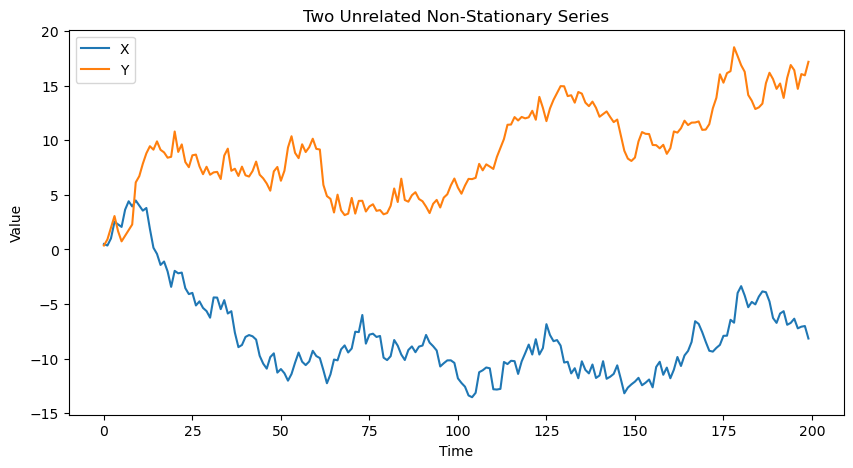

In [15]:
df.plot(title="Two Unrelated Non-Stationary Series", figsize=(10,5))
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


In [16]:
for col in ['X', 'Y']:
    result = adfuller(df[col])
    print(f"{col}: p-value = {result[1]:.4f}")


X: p-value = 0.1696
Y: p-value = 0.3707


In [17]:
X = sm.add_constant(df['X'])
model = sm.OLS(df['Y'], X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     3.651
Date:                Mon, 27 Oct 2025   Prob (F-statistic):             0.0575
Time:                        14:15:23   Log-Likelihood:                -563.39
No. Observations:                 200   AIC:                             1131.
Df Residuals:                     198   BIC:                             1137.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0128      0.633     12.665      0.0

In [18]:
df['X_diff'] = df['X'].diff()
df['Y_diff'] = df['Y'].diff()
df = df.dropna()


In [19]:
for col in ['X_diff', 'Y_diff']:
    result = adfuller(df[col])
    print(f"{col}: p-value = {result[1]:.4f}")


X_diff: p-value = 0.0000
Y_diff: p-value = 0.0000


In [20]:
X_diff = sm.add_constant(df['X_diff'])
model_diff = sm.OLS(df['Y_diff'], X_diff).fit()
print(model_diff.summary())


                            OLS Regression Results                            
Dep. Variable:                 Y_diff   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.773
Date:                Mon, 27 Oct 2025   Prob (F-statistic):              0.185
Time:                        14:15:57   Log-Likelihood:                -278.84
No. Observations:                 199   AIC:                             561.7
Df Residuals:                     197   BIC:                             568.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0889      0.070      1.268      0.2